In [12]:
%%javascript
IPython.notebook.kernel.execute('nb_name = "' + IPython.notebook.notebook_name + '"')

<IPython.core.display.Javascript object>

In [1]:
%load_ext autoreload
%autoreload 2
import os
from tqdm import tqdm
import wandb
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, models

import sys
sys.path.append('../../../helper_functions/')
from visualization_functions import show_images

sys.path.append('../src/')
from h5_functions import list_to_dict, hdf5_dataset, viz_dataloader

symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

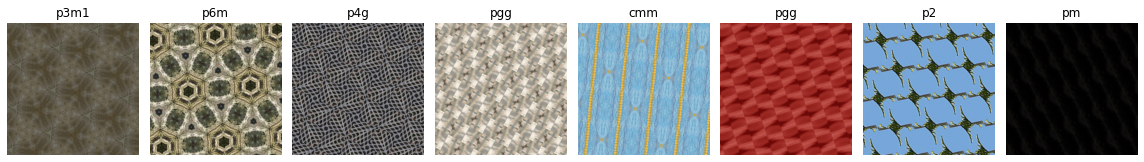

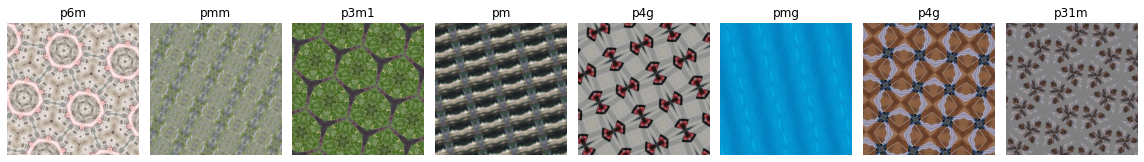

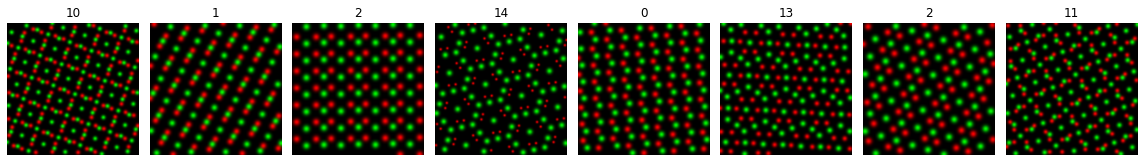

CPU times: user 30.7 s, sys: 948 ms, total: 31.7 s
Wall time: 9.3 s


In [2]:
%%time
# imagenet
train_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset.h5', folder='train', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter)

# train_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_2m_valid_unchunked.h5', folder='valid', transform=transforms.ToTensor())
# train_dl = DataLoader(train_ds, batch_size=230, shuffle=True, num_workers=2)
# viz_dataloader(train_dl, label_converter=label_converter)

valid_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset.h5', folder='valid', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=64, shuffle=True, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter)

test_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset.h5', folder='test', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=64, shuffle=True, num_workers=4)
viz_dataloader(test_dl)

In [3]:
from ae_customized import Autoencoder
model = Autoencoder()
out = model(torch.randn(2,3,256,256))
out[0].shape, out[1].shape

(torch.Size([2, 17]), torch.Size([2, 3, 256, 256]))

In [4]:
def train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                 epochs, start=0, scheduler=None, model_name=None, model_dir=None, tracking=False):

    # make directory for the model
    if model_dir and not os.path.isdir(model_dir): os.mkdir(model_dir)

    history = []
    
    if tracking:   
        wandb.watch(model, log_freq=100)
        
    for epoch_idx in range(start, epochs+start):
                
        print("Epoch: {}/{}".format(epoch_idx+1, epochs+start))
        
        avg_train_loss_mse, avg_train_loss_cross_entropy, avg_train_acc = iterate_dl(model, loss_func, 'train', device=device, imagenet_dl=train_dl, atom_dl=test_dl, 
                                                                                     optimizer=optimizer, scheduler=scheduler, tracking=tracking)
        
        avg_valid_loss_mse, avg_valid_loss_cross_entropy, avg_valid_acc = iterate_dl(model, loss_func, 'valid', device=device, imagenet_dl=valid_dl, atom_dl=test_dl, tracking=tracking)
        
        if test_dl:
            avg_test_loss_mse, avg_test_loss_cross_entropy, avg_test_acc = iterate_dl(model, loss_func, 'valid', device=device, imagenet_dl=test_dl, atom_dl=test_dl, tracking=tracking)
            
        if tracking:   
            # record the epoch loss and accuracy:            
            wandb.log({'epoch':epoch_idx, 
                        "train_loss_cross_entropy": avg_train_loss_cross_entropy,
                        "train_loss_mse": avg_train_loss_mse,
                        "train_acc": avg_train_acc, 

                        "valid_loss_cross_entropy": avg_valid_loss_cross_entropy,
                        "valid_loss_mse": avg_valid_loss_mse,
                        "valid_acc": avg_valid_acc,
                        
                        "test_loss_cross_entropy": avg_test_loss_cross_entropy,
                        "test_loss_mse": avg_test_loss_mse,
                        "test_acc": avg_test_acc})
                
        if model_name != None:
            torch.save(model, os.path.join(model_dir, model_name+'-epoch-{}.pt'.format(epoch_idx+1)))
                
    return history


def iterate_dl(model, loss_func, mode, device, imagenet_dl, atom_dl, optimizer=None, scheduler=None, tracking=False):

    imagenet_data_size = len(imagenet_dl.dataset)
    atom_data_size = len(atom_dl.dataset)

    if mode == 'train':
        # Set to training mode
        model.train()

    # Loss and Accuracy within the epoch
    acc_sum = 0.0
    loss_cross_entropy_sum = 0.0
    loss_mse_sum = 0.0

    # Create iterators for the data loaders
    imagenet_iter = iter(imagenet_dl)
    atom_iter = iter(atom_dl)
    length = min(len(imagenet_dl), len(atom_dl))

    for i in tqdm(range(length)):
        model = model.to(device)

        # imagenet
        imagenet_batch = next(imagenet_iter)
        inputs_imagenet = imagenet_batch[0].to(device).float()
        labels_imagenet = imagenet_batch[1].to(device).long()
        outputs, _ = model(inputs_imagenet)
        loss_cross_entropy = nn.CrossEntropyLoss()(outputs, labels_imagenet)
        
        # atom
        atom_batch = next(atom_iter)
        inputs_atom = atom_batch[0].to(device).float()
        _, reconstructions = model(inputs_atom)
        loss_mse = nn.MSELoss()(reconstructions, inputs_atom) 

        # Compute loss
        loss = loss_cross_entropy + loss_mse

        if mode == 'train':
            # Clean existing gradients
            optimizer.zero_grad()

            # Backpropagate the gradients
            loss.backward()

            # Update the parameters
            optimizer.step()
            if scheduler:
                scheduler.step()
            
        # Compute the accuracy
        ret, predictions = torch.max(outputs.data, 1)
        correct_counts = predictions.eq(labels_imagenet.data.view_as(predictions))

        # Convert correct_counts to float and then compute the mean
        acc = torch.mean(correct_counts.type(torch.FloatTensor))

        # Compute the total loss for the batch and add it to train_loss
        loss_cross_entropy_sum += loss_cross_entropy.item() * inputs_imagenet.size(0)
        loss_mse_sum += loss_mse.item() * inputs_imagenet.size(0)
        # Compute total accuracy in the whole batch and add to train_acc
        acc_sum += acc.item() * inputs_imagenet.size(0)
        
        if tracking: 
            if mode == 'train':  
                wandb.log({'step':i, 
                            "train_loss_cross_entropy": loss_cross_entropy_sum, 
                            "train_loss_mse": loss_mse_sum})

            if mode == 'valid':  
                wandb.log({'step':i, 
                            "valid_loss_cross_entropy": loss_cross_entropy_sum, 
                            "valid_loss_mse": loss_mse_sum})
                
    # Find average training loss and training accuracy
    avg_loss_cross_entropy = loss_cross_entropy_sum/imagenet_data_size 
    avg_loss_mse = loss_mse_sum/atom_data_size 
    avg_acc = acc_sum/float(imagenet_data_size)
    
    if mode == 'train':  
        print(f"Training: ImageNet MSE Loss: {avg_loss_mse:.4f}, Cross Entropy Loss: {avg_loss_cross_entropy:.4f}, Accuracy: {avg_acc*100:.4f}%")
    if mode == 'valid':  
        print(f"Validation: ImageNet MSE Loss: {avg_loss_mse:.4f}, Cross Entropy Loss: {avg_loss_cross_entropy:.4f}, Accuracy: {avg_acc*100:.4f}%")

    return avg_loss_mse, avg_loss_cross_entropy, avg_acc

In [5]:
config = {
    'dataset': '/scratch/yichen/imagenet_v4_rot_10m_train_unchunked.h5',
    'device': torch.device('cuda:0'),
    'loss_func': 'CrossEntropyLoss and MSELoss' , # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
    'dropout': 0.5
}

NAME = '10242023-resnet_ae_semi-supervised'

# train

In [6]:
%%javascript
IPython.notebook.kernel.execute('nb_name = "' + IPython.notebook.notebook_name + '"')

<IPython.core.display.Javascript object>

In [7]:
# os.environ["WANDB_NOTEBOOK_NAME"] = nb_name
wandb.init(project='symmetry_paper', entity='yig319', name=NAME, id=NAME, save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [8]:
device = config['device']
lr = 1e-3
start = 0
epochs = 50

loss_func = [nn.CrossEntropyLoss(), nn.MSELoss()]
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(test_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl, epochs=epochs, start=start, scheduler=scheduler, 
                       model_name=NAME, model_dir='/scratch/yichen/models_new/', tracking=True)

Epoch: 1/50


100%|██████████| 1563/1563 [07:49<00:00,  3.33it/s]


Training: ImageNet MSE Loss: 0.0564, Cross Entropy Loss: 3.0173, Accuracy: 6.1630%


100%|██████████| 1563/1563 [03:23<00:00,  7.68it/s]


Validation: ImageNet MSE Loss: 0.0263, Cross Entropy Loss: 2.9579, Accuracy: 6.1490%


...


100%|██████████| 1563/1563 [03:29<00:00,  7.46it/s]


Validation: ImageNet MSE Loss: 0.0019, Cross Entropy Loss: 5.7132, Accuracy: 18.6800%
Epoch: 35/50


100%|██████████| 1563/1563 [07:15<00:00,  3.59it/s]


Training: ImageNet MSE Loss: 0.0019, Cross Entropy Loss: 0.4338, Accuracy: 84.5010%


 57%|█████▋    | 897/1563 [01:59<01:30,  7.38it/s]

In [ ]:
model = torch.load('/scratch/yichen/models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-19.pt')

In [ ]:
device = config['device']
lr = 1e-3
start = 50
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler_imagenet = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))
scheduler_atom = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(test_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=start, scheduler_imagenet=scheduler_imagenet, scheduler_atom=scheduler_atom, model_name=NAME, 
                       model_dir='/mnt/d/models/', tracking=True)

# analyze

In [7]:
model = torch.load('/scratch/yichen/models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-19.pt')

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

# imagenet 
def confusion_matrix(model, dataloader, classes, device, n_batches=1):
    model.eval()
    cm = torch.zeros(len(classes), len(classes))
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(tqdm(dataloader)):
            inputs = inputs.to(device) 
            labels = labels.to(device)
            model = model.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            for t, p in zip(labels.view(-1), preds.view(-1)):
                cm[t.long(), p.long()] += 1
    cm = np.array(cm)

    print('Sum for true labels:')
    true_counts = np.expand_dims(np.sum(cm, axis=1), 0)
    display(pd.DataFrame(true_counts, columns=classes))

    wrong, right = 0, 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i == j: right+=cm[i,j]
            if i != j: wrong+=cm[i,j]
    print('Accuracy for these batches:', right/(right+wrong))
    return cm.astype(np.int32)

def plot_cm(cm, classes, save_file, title, style='simple'):

    if style == 'simple':
        fig = plt.figure(figsize=(12,10))
        ax = fig.subplots(1,1)
        ax.set_title('Confusion Matrix of'+title)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
        disp = disp.plot(cmap=plt.cm.Blues, ax=ax)

    if style== 'with_axis':
        df_cm = pd.DataFrame(cm)
        df_cm.index.name = 'Actual'
        df_cm.columns.name = 'Predicted'

        fig = plt.figure(figsize=(12,10))
        ax = fig.subplots(1,1)
        ax.set_title('Confusion Matrix of'+title)

        res = sn.heatmap(df_cm, annot=True, square=True, cmap='Blues',
                         xticklabels = classes, yticklabels=classes, fmt='g', 
                         ax=ax, cbar_kws={'label': 'Number of Images'})

        res.axhline(y = 0, color = 'k', 
                    linewidth = 1)
        res.axhline(y = 16.98, color = 'k',
                    linewidth = 1)
        res.axvline(x = 0, color = 'k',
                    linewidth = 1)
        res.axvline(x = 16.98, color = 'k',
                    linewidth = 1)
    
    if save_file: plt.savefig(save_file, dpi=300)
    plt.show()

NAME = 'benchmark-resnet50_from_scratch-v4_10m-05312023'
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                    'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']

In [9]:
device = torch.device('cuda:2')

cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-train_cm.npy', cm)

100%|██████████| 43479/43479 [2:17:30<00:00,  5.27it/s]  


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,588308.0,588239.0,588239.0,588233.0,588232.0,588231.0,588236.0,588232.0,588239.0,588237.0,588238.0,588239.0,588239.0,588224.0,588239.0,588238.0,588237.0


Accuracy for these batches: 0.9996354029167767


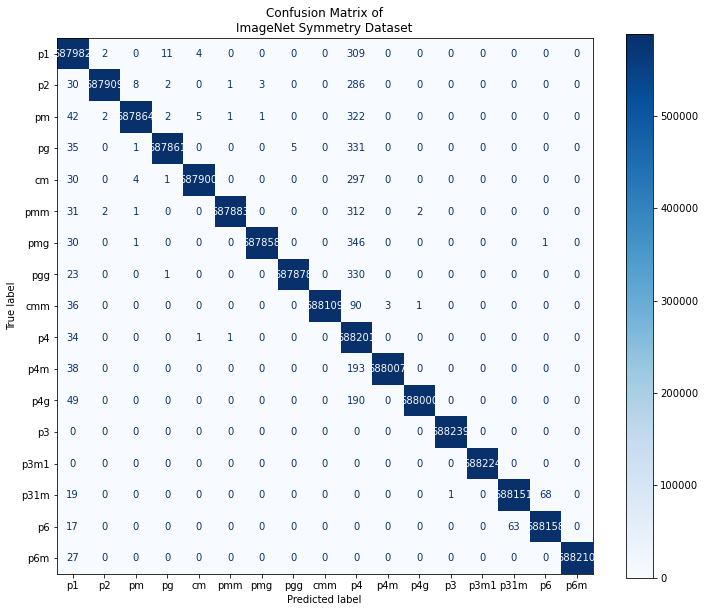

In [10]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [11]:
cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-valid_cm.npy', cm)

100%|██████████| 8696/8696 [27:55<00:00,  5.19it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,117670.0,117647.0,117647.0,117647.0,117646.0,117646.0,117648.0,117647.0,117647.0,117646.0,117647.0,117648.0,117647.0,117645.0,117645.0,117646.0,117647.0


Accuracy for these batches: 0.9991540067679459


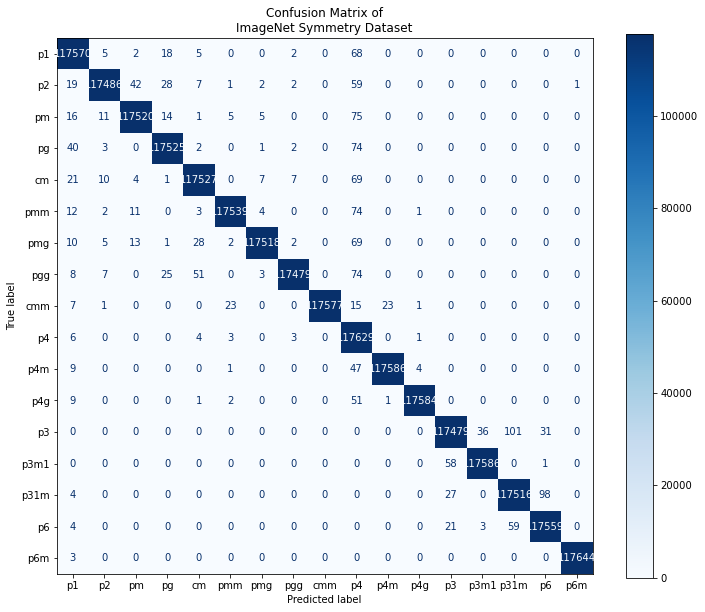

In [12]:
# cm = np.load('11172021-benchmark_imagenet-fpn_spatial-transfer_learning-valid.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [13]:
cm = confusion_matrix(model, test_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-test_cm.npy', cm)

100%|██████████| 1985/1985 [29:26<00:00,  1.12it/s]


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,270351.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0


Accuracy for these batches: 0.5805782531969523


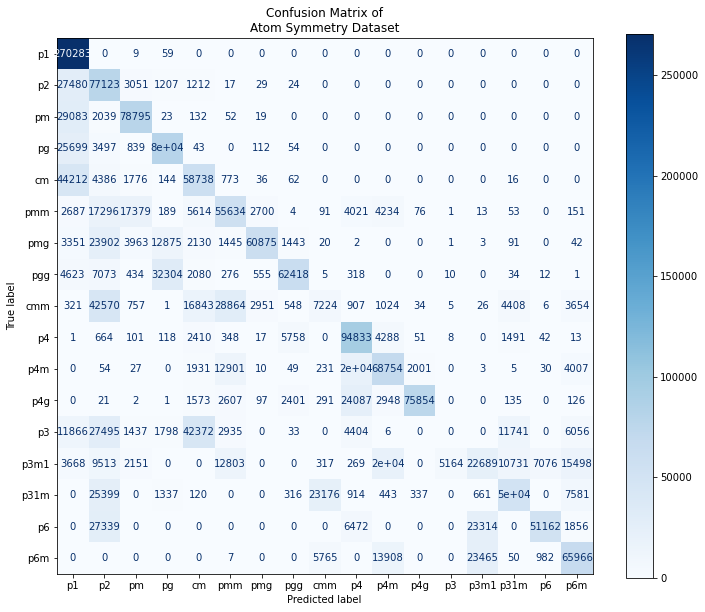

In [14]:
# cm = np.load('05232022-benchmark-resnet50_from_scratch-dataset_v3-test.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nAtom Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
import sys
sys.path.append('../../../helper_functions/')
from python_email import send_email
send_email()

In [ ]:
from IPython.display import display_html
def restartkernel() :
    display_html("<script>Jupyter.notebook.kernel.restart()</script>",raw=True)
restartkernel()